In [1]:
# Setup: Add repository to path for importing custom modules
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parent
sys.path.append(str(repo_root))

In [ ]:
# Import custom modules
from scripts.db.db_utils import fetch_ids
from scripts.features.motion_features import summarize_speed_from_ids
from scripts.plots.feature_barplot import barplot_mean_se

In [3]:
# ChickenBroth task: Compare speed between Saline (Y) and Ghrelin (P) treatments
query1 = "SELECT id FROM experimental_metadata WHERE task = 'ChickenBroth' AND treatment = 'Y';"
query2 = "SELECT id FROM experimental_metadata WHERE task = 'ChickenBroth' AND treatment = 'P';"

ids_y = fetch_ids(query1)
ids_p = fetch_ids(query2)

speed_y = summarize_speed_from_ids(ids_y)
speed_p = summarize_speed_from_ids(ids_p)

# print("ChickenBroth-Saline:", speed_y)
# print("ChickenBroth-Ghrelin:", speed_p)


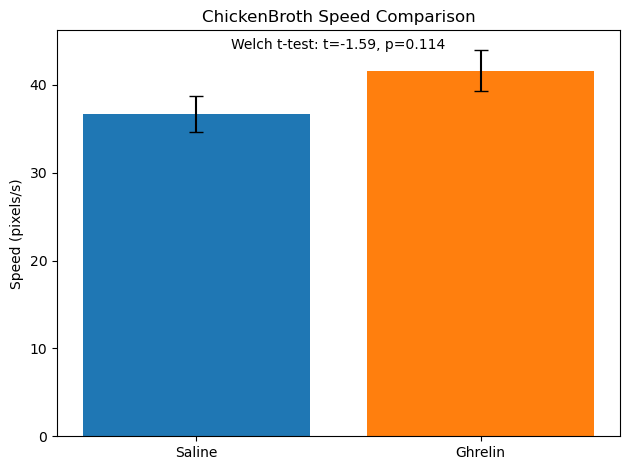

In [4]:
results_dir = repo_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

barplot_mean_se(
    speed_y,
    speed_p,
    labels=["Saline", "Ghrelin"],
    ylabel="Speed (pixels/s)"
)

import matplotlib.pyplot as plt
plt.title("ChickenBroth Speed Comparison")
plt.tight_layout()
plt.savefig(results_dir / "chickenbroth_speed.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
I was thinking of writing a python script/module in which I can do the following: